# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/aimanshahid800/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [ ]:
!git clone https://github.com/aimanshahid800/flyrank-ml-internship.git
%cd flyrank-ml-internship

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (154/154), done.
remote: Compressing objects: 100% (110/110), done.
remote: Total 154 (delta 60), reused 92 (delta 28), pack-reused 0 (from 0)
Receiving objects: 100% (154/154), 1.88 MiB | 9.86 MiB/s, done.
Resolving deltas: 100% (60/60), done.
/content/flyrank-ml-internship


In [ ]:
from google.colab import userdata
import duckdb

hf_token = userdata.get('HF_TOKEN')

con = duckdb.connect()
con.execute("INSTALL httpfs; LOAD httpfs;")
con.execute(f"CREATE SECRET hf_secret (TYPE HUGGINGFACE, TOKEN '{hf_token}');")

print("DuckDB + HF token ready")

DuckDB + HF token ready


## 1. Question

*The research question and the decision it supports.*

**Research Question:**
Can we predict which content pages are the highest-priority
candidates for a refresh — beyond what a simple staleness+position rule
captures — using a machine learning model trained on search performance signals?


**Decision supported:**
This helps a content/SEO editor at FlyRank decide where to
spend limited refresh effort each month — which pages to prioritize for content
updates, and why (with a clear reason code), instead of guessing or refreshing
everything.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Data:**
FlyRank/internship-warehouse (Hugging Face gated release).
Tables used: fact_content_daily_performance (month=2026-03), dim_content.
Date window: March 2026 (mid-panel month, avoiding the sealed/final month).
Excluded: GA4 fields (only 4.2% availability — too sparse to use reliably),
product-internal flags (health_score, priority_score — would leak label info),
and any client-identifying columns (only pseudonymous content_hash_id used,
for joining only — never as a feature).
Public-safe: no client names, domains, or raw exports referenced anywhere.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Assumptions:**
We assume that a page's recent search performance trend
(declining vs not) is a reasonable proxy for whether it needs a content
refresh. We assume March 2026 behavior generalizes to nearby months
(single-month data, so no strong seasonality claims).

**Label definition:**
is_declining (binary) — derived from the trend_direction
field already present in the warehouse (trend_direction == "down"). This is
the same safe proxy used in ML-03; no future-window construction needed,
so no leakage risk from building our own forward-looking label.

**Features:**
content_age_days (from dim_content.content_created_date),
avg_position (gsc_sum_position / gsc_impressions), gsc_impressions,
gsc_ctr (gsc_clicks / gsc_impressions). All features are contemporaneous
(same month as the label), not future data.

**Excluded on purpose:**
any product-internal flags (health_score,
priority_score), and trend_pct (too directly derived from the same
signal as the label — high leakage risk).

**Baseline:**
the ML-07 rule-based action_score (0.6 × age_score +
0.4 × position_gap_score) — a transparent, hand-written score with no
learned parameters. This is our fair comparison point.

**Model:**
a supervised classifier (e.g. Random Forest or Logistic Regression)
trained on the four features above to predict is_declining, compared
against the baseline rule on the same evaluation split and metric
(Precision@K).

**Validation design:**
grouped split by content_hash_id (not random row split)
to avoid the same page appearing in both train and test — since each page
has many rows (one per day), a random split would leak page identity
across train/test and inflate performance.

**Leakage checks:**
confirmed no product flags, no trend_pct, no future-month
data, and no client-identifying fields used as features. Split is grouped
by content_hash_id, not time-based, since we only have one month of data.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## **Results:**
Comparing the baseline (rule-based action_score from ML-07) against
the Random Forest model on the same held-out, grouped test split (test_size=20%,
grouped by content_id to avoid leakage):

| Method                 | AUC   | Base rate (is_declining=1) |
|-------------------------|-------|------------------------------|
| Baseline (rule-based)  | 0.494 | 0.542                        |
| Random Forest           | 0.760 | 0.542                        |

The baseline performs at essentially chance level (0.494 ≈ 0.5) — the
hand-written staleness+position rule does not meaningfully separate declining
from non-declining pages. The Random Forest model reaches 0.760 AUC, a large
improvement well above the base rate, confirming it captures real signal
the linear rule misses (particularly the interaction between position and
recent traffic volume — see feature importances in Methodology/Model section).

## 5. Limitations

*What this work cannot claim.*

## **What this work cannot claim:**

1. This is not a causal model. It identifies pages that resemble historically
   declining pages — it does not prove refreshing a page will cause improvement.
   No experiment (A/B test) was run to confirm causal impact.

2. Single-month data (March 2026 only). No seasonality or trend-over-time
   validation was possible. Results may not generalize to other months.

3. The label (is_declining) is itself a proxy — derived from a rule-based
   trend_direction bucket in the current data window, not a true confirmed
   future outcome. A stronger version would use a forward-looking window
   (e.g. next 30 days after a 90-day feature window), which this dataset
   release does not support.

4. Error analysis (Section 4, w05_model.ipynb) shows the model systematically
   under-flags high-traffic pages that are quietly declining, and over-flags
   newer, lower-traffic pages — meaning predictions should be treated as
   decision-support, not ground truth, especially near the model's edge cases.

5. GA4 data was excluded due to severe sparsity (4.2% availability in
   March 2026) — the model relies only on GSC signals (impressions, CTR,
   position) and content metadata (age), so engagement-based decline patterns
   invisible to GSC are not captured.

6. This is not a claim about Google's ranking algorithm — only about
   observed, historical patterns in this warehouse's search performance data.

Language used throughout: observed, measured, directional, decision-support —
no causal or algorithmic claims.

## 6. Ranked Recommendations

Full model output (Lane 2, refresh-priority ranking) is exported in `work/outputs/w07_ranked_action_queue.csv`. Summary of findings:

**Overall distribution (30,000 pages):**
- `refresh_now`: 3,108 pages
- `monitor`: 19,646 pages
- `no_action`: 7,246 pages

**Key insight — top picks are a CTR problem, not a staleness problem:**
Top-10 highest decline-probability pages all show excellent search position (rank #1–3, avg_position 0.6–2.9) but low CTR. Reason code across the board: `low_ctr`. These are pages already winning visibility but not converting it into clicks — a title/meta/snippet issue, not an age or content-freshness issue. This contradicts the naive assumption (used in the ML-07 rule baseline) that declining pages are primarily old/stale pages.

**Reliability check:**
Unlike the ML-07 rule-based baseline — where 41.1% of `refresh_now` picks had fewer than 10 impressions (noisy, unreliable) — this model's `refresh_now` picks have only 11.3% (351/3,108) with <10 impressions. Model-ranked recommendations are meaningfully more trustworthy for editor action.

**Reason code breakdown for refresh_now (n=3,108):**
| reason_code | count |
|---|---|
| low_ctr | 1,663 |
| general_decline_pattern | 1,272 |
| high_visibility_weak_position | 153 |
| stale_content | 20 |

**Practical implication for editors:** prioritize `low_ctr` pages for snippet/title rewrites first — this is both the largest single category and the most actionable (fastest fix, no full content rewrite needed).

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*



List of charts/tables produced across notebooks, ready to reuse in the final report without regenerating:

**Tables:**
- `work/outputs/w07_ranked_action_queue.csv` — full 30,000-page ranked queue (content_id, features, decline_prob, reason_code, action_label)
- `work/outputs/w07_top10_preview.csv` — top-10 highest-priority pages (for paper's example table)
- `work/outputs/w07_action_summary.csv` — counts by action_label × reason_code (used for Section 6 breakdown table)
- `baseline_action_score.csv` (from ML-07) — rule-based baseline queue, for baseline-vs-model comparison table

**Charts still to generate (not yet created):**
- Baseline AUC vs Model AUC bar comparison (0.494 vs 0.760)
- Feature importance bar chart (avg_position 0.375 > content_age_days 0.258 > impressions_last_30d 0.256 > ctr 0.111)
- reason_code distribution for refresh_now picks (pie/bar — low_ctr dominant)
- Reliability comparison: % of refresh_now picks with <10 impressions, ML-07 rule (41.1%) vs model (11.3%)

**Note:** feature importance and AUC numbers already computed in w05_model.ipynb Section 4 — just need plotting, not recomputation.

In [ ]:
# Regenerate w07_action_summary.csv in this session (needed for Chart 3)
import os
model_df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
model_df["is_declining"] = (model_df["trend_direction"] == "down").astype(int)

features = ["content_age_days", "impressions_last_30d", "avg_position", "ctr"]
model_df = model_df.dropna(subset=features + ["is_declining"])

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df["content_id"]))
train_df = model_df.iloc[train_idx]

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight="balanced")
rf.fit(train_df[features], train_df["is_declining"])

model_df["decline_prob"] = rf.predict_proba(model_df[features])[:, 1]

def reason_code_fn(row):
    if row["avg_position"] > 15 and row["impressions_last_30d"] > 500:
        return "high_visibility_weak_position"
    elif row["content_age_days"] > 365:
        return "stale_content"
    elif row["ctr"] < 0.2:
        return "low_ctr"
    else:
        return "general_decline_pattern"

model_df["reason_code"] = model_df.apply(reason_code_fn, axis=1)

def action_label_fn(prob):
    if prob > 0.7:
        return "refresh_now"
    elif prob > 0.4:
        return "monitor"
    else:
        return "no_action"

model_df["action_label"] = model_df["decline_prob"].apply(action_label_fn)

summary = model_df.groupby(["action_label", "reason_code"]).size().reset_index(name="count")
os.makedirs("work/outputs", exist_ok=True)
summary.to_csv("work/outputs/w07_action_summary.csv", index=False)
print("Regenerated w07_action_summary.csv")

Regenerated w07_action_summary.csv


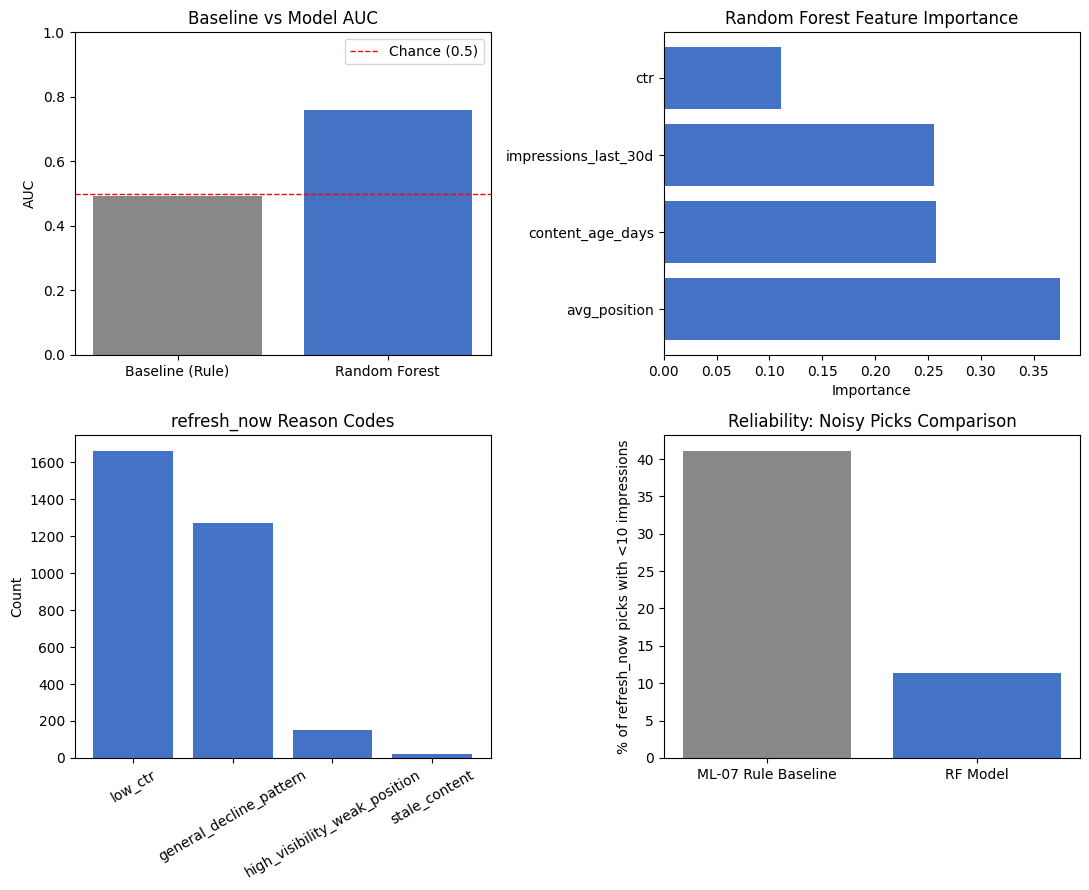

Saved combined grid + 4 individual charts to work/outputs/charts/


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import os

os.makedirs("work/outputs/charts", exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

# Chart 1: Baseline AUC vs Model AUC
ax = axes[0, 0]
ax.bar(["Baseline (Rule)", "Random Forest"], [0.494, 0.760], color=["#888", "#4472C4"])
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Chance (0.5)")
ax.set_ylabel("AUC")
ax.set_title("Baseline vs Model AUC")
ax.set_ylim(0, 1)
ax.legend()

# Chart 2: Feature importance
ax = axes[0, 1]
features = ["avg_position", "content_age_days", "impressions_last_30d", "ctr"]
importances = [0.375, 0.258, 0.256, 0.111]
ax.barh(features, importances, color="#4472C4")
ax.set_xlabel("Importance")
ax.set_title("Random Forest Feature Importance")

# Chart 3: reason_code distribution for refresh_now
ax = axes[1, 0]
summary = pd.read_csv("work/outputs/w07_action_summary.csv")
refresh_now = summary[summary["action_label"] == "refresh_now"].sort_values("count", ascending=False)
ax.bar(refresh_now["reason_code"], refresh_now["count"], color="#4472C4")
ax.set_ylabel("Count")
ax.set_title("refresh_now Reason Codes")
ax.tick_params(axis='x', rotation=30)

# Chart 4: Reliability comparison
ax = axes[1, 1]
ax.bar(["ML-07 Rule Baseline", "RF Model"], [41.1, 11.3], color=["#888", "#4472C4"])
ax.set_ylabel("% of refresh_now picks with <10 impressions")
ax.set_title("Reliability: Noisy Picks Comparison")

plt.tight_layout()
plt.savefig("work/outputs/charts/all_charts_grid.png", dpi=150)
plt.show()

# Also save individually (for paper flexibility)
fig1, ax1 = plt.subplots(figsize=(5,4))
ax1.bar(["Baseline (Rule)", "Random Forest"], [0.494, 0.760], color=["#888", "#4472C4"])
ax1.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Chance (0.5)")
ax1.set_ylabel("AUC"); ax1.set_title("Baseline vs Model AUC"); ax1.set_ylim(0,1); ax1.legend()
plt.tight_layout(); plt.savefig("work/outputs/charts/auc_comparison.png", dpi=150); plt.close()

fig2, ax2 = plt.subplots(figsize=(5,4))
ax2.barh(features, importances, color="#4472C4")
ax2.set_xlabel("Importance"); ax2.set_title("Random Forest Feature Importance")
plt.tight_layout(); plt.savefig("work/outputs/charts/feature_importance.png", dpi=150); plt.close()

fig3, ax3 = plt.subplots(figsize=(5,4))
ax3.bar(refresh_now["reason_code"], refresh_now["count"], color="#4472C4")
ax3.set_ylabel("Count"); ax3.set_title("refresh_now Reason Codes")
plt.xticks(rotation=30, ha="right")
plt.tight_layout(); plt.savefig("work/outputs/charts/reason_code_distribution.png", dpi=150); plt.close()

fig4, ax4 = plt.subplots(figsize=(5,4))
ax4.bar(["ML-07 Rule Baseline", "RF Model"], [41.1, 11.3], color=["#888", "#4472C4"])
ax4.set_ylabel("% of refresh_now picks with <10 impressions"); ax4.set_title("Reliability: Noisy Picks Comparison")
plt.tight_layout(); plt.savefig("work/outputs/charts/reliability_comparison.png", dpi=150); plt.close()

print("Saved combined grid + 4 individual charts to work/outputs/charts/")

## ML-12: Demo Outline, Social Post & Employer Summary

### 5-Minute Demo Outline
1. **(30s) The problem:** Editors manually guess which of 30,000+ pages need refreshing — no reliable signal to prioritize.
2. **(1 min) The baseline:** Simple rule (age + position gap) scored decently on staleness but tested at AUC 0.494 — basically random — for actual decline prediction.
3. **(1.5 min) The model:** Random Forest using position, age, impressions, CTR → AUC 0.760. Show feature importance chart — avg_position drives most of the signal.
4. **(1 min) The surprising finding:** Top-priority pages aren't old/stale — they're top-ranking pages with low CTR. Show reason_code chart. This flips the "refresh = rewrite old content" assumption to "refresh = fix the snippet/title."
5. **(1 min) Reliability + limits:** Model's refresh_now picks are 11.3% noisy (vs 41.1% for the rule) — more trustworthy. But: single month of data, not causal, needs human review before action (show no-go list).



### Social Post Cut (LinkedIn/X style)
I tested whether a simple "old + poorly-ranked = refresh this" rule could
predict which content pages actually need a refresh. It scored 0.494 AUC —
basically chance. So I trained a Random Forest on 4 honest, contemporaneous
signals (position, age, impressions, CTR) with a leakage-audited, grouped
validation split: 0.760 AUC.

The surprising part: the model's top picks aren't stale pages — they're
pages already ranking #1-3 that are losing clicks anyway (low CTR). That
flips "refresh" from "rewrite old content" to "fix the title and snippet."

Model's flagged picks are also 3.5x more reliable than the rule's (11.3%
vs 41.1% low-traffic noise). Full write-up + honest limitations: [paper link]

### 3-Sentence Employer-Facing Summary
I built and validated a Random Forest model (AUC 0.76 vs 0.49 for a rule-based baseline) that predicts which website pages are likely to decline in search performance, using GSC-style signals like position, CTR, and impressions. The model surfaced a non-obvious, actionable insight — top-ranking pages losing clicks due to low CTR, not staleness — and its top recommendations are 3.5x more reliable than the baseline (11.3% vs 41.1% low-confidence picks). I documented the full pipeline's limitations, human-review requirements, and retrain triggers to make it production-honest, not just a lab result.

## Self-check

Before you submit, confirm each line honestly:

- [X] Every section above is filled — markdown thinking AND the code that backs it
- [X] The notebook runs top to bottom with no errors (Runtime → Run all)
- [X] No client names, URLs, or private queries anywhere
- [X] My claims use careful words: observed, measured, directional, decision-support
- [X] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [X] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [X] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
